<a href="https://colab.research.google.com/github/Oalawamry/NucSegment/blob/main/Refining_Model_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Environment and loading files if not already in directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[gdown, nibabel, tqdm, ignite]"
!python -c "import matplotlib" || pip install -q matplotlib

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 65.2 MB/s eta 0:00:00


In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [ ]:
from monai.utils import first, set_determinism
from monai.transforms import (
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    Invertd,
    Lambdad,
)
from monai.handlers.utils import from_engine
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract
import torch
import matplotlib.pyplot as plt
import tempfile
import shutil
import os
import glob

### Download dataset from kaggle or copy from mounted drive

if neither possible, upload zip file to current directory

In [ ]:
#!kaggle competitions download -c data-science-bowl-2018 #needs authentication, alternatively upload file

In [ ]:
drive_zip_path = '/content/drive/MyDrive/nuclei_labeling/data-science-bowl-2018.zip'
local_zip_path = '/content/data-science-bowl-2018.zip'

print(f"Drive ZIP Path: {drive_zip_path}")
print(f"Local ZIP Path: {local_zip_path}")

Drive ZIP Path: /content/drive/MyDrive/nuclei_labeling/data-science-bowl-2018.zip
Local ZIP Path: /content/data-science-bowl-2018.zip


In [ ]:
import os
import shutil

# Check if the local zip file exists
if os.path.exists(local_zip_path):
    print(f"Dataset already exists locally at {local_zip_path}. Skipping copy.")
else:
    print(f"Dataset not found locally. Checking Google Drive at {drive_zip_path}...")
    # Check if the source exists on Google Drive
    if os.path.exists(drive_zip_path):
        print("File found on Drive. Copying to local environment...")
        shutil.copy(drive_zip_path, local_zip_path)
        print("Copy complete.")
    else:
        print(f"WARNING: Dataset not found on Google Drive at {drive_zip_path}. Please ensure the file is in your Drive or upload it manually.")

Dataset not found locally. Checking Google Drive at /content/drive/MyDrive/nuclei_labeling/data-science-bowl-2018.zip...
File found on Drive. Copying to local environment...
Copy complete.


In [ ]:
train_dir = 'data/stage1_train'
test_dir = 'data/stage1_test'

In [ ]:
!ls

data-science-bowl-2018.zip  drive  sample_data


In [ ]:
!unzip -n data-science-bowl-2018.zip -d data


Archive:  data-science-bowl-2018.zip
  inflating: data/stage1_sample_submission.csv.zip  
  inflating: data/stage1_solution.csv.zip  
  inflating: data/stage1_test.zip    
  inflating: data/stage1_train.zip   
  inflating: data/stage1_train_labels.csv.zip  
  inflating: data/stage2_sample_submission_final.csv.zip  
  inflating: data/stage2_test_final.zip  


In [ ]:
!for f in data/*.zip; do folder="${f%.zip}"; unzip -n "$f" -d "$folder"; done



Streaming output truncated to the last 5000 lines.
   creating: data/stage2_test_final/14ff49df48363b4f950a49c08313d933273fe9058dbda881d9579a1700e16dc8/images/
  inflating: data/stage2_test_final/14ff49df48363b4f950a49c08313d933273fe9058dbda881d9579a1700e16dc8/images/14ff49df48363b4f950a49c08313d933273fe9058dbda881d9579a1700e16dc8.png  
   creating: data/stage2_test_final/34d0fa5fd2fe5c9955fff299ead6ce97366a2176ad7569afc279c25ba6e0e231/images/
  inflating: data/stage2_test_final/34d0fa5fd2fe5c9955fff299ead6ce97366a2176ad7569afc279c25ba6e0e231/images/34d0fa5fd2fe5c9955fff299ead6ce97366a2176ad7569afc279c25ba6e0e231.png  
   creating: data/stage2_test_final/73cd786850fd7161e2b4bc557dbf6743a70cd69f511317c1546d5bb9fd326e17/images/
  inflating: data/stage2_test_final/73cd786850fd7161e2b4bc557dbf6743a70cd69f511317c1546d5bb9fd326e17/images/73cd786850fd7161e2b4bc557dbf6743a70cd69f511317c1546d5bb9fd326e17.png  
   creating: data/stage2_test_final/19699898bd07e3d27804bc52fea46d67a8d4c63ec75b56939

# Trying new transforms

In [ ]:
from monai.transforms.intensity.dictionary import ScaleIntensityRangePercentilesd
from monai.transforms import DivisiblePadd, Resized

# Training Transform
train_transform = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        Lambdad(keys="image", func=lambda x: x[0:1, :, :]), # Selects the first channel for the image
        # Combine all labels into a single binary mask and ensure values are only 0 or 1
        Lambdad(keys="label", func=lambda x: (torch.max(x, dim=0, keepdim=True)[0] > 0).float()),
        ScaleIntensityRangePercentilesd(keys="image", lower=0.5, upper=99.5, b_min=0, b_max=1),
        RandCropByPosNegLabeld(keys=['image', 'label'], spatial_size = (256, 256), label_key= 'label', neg=0, num_samples=4)
        # Resized(keys=["image", "label"], spatial_size=(256, 256), mode=["area", "nearest"])
    ]
)

# Validation Transform
val_transform = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        CropForegroundd(keys=["image", "label"], source_key="image"),
        Lambdad(keys="image", func=lambda x: x[0:1, :, :]), # Selects the first channel for the image
        # Combine all labels into a single binary mask and ensure values are only 0 or 1
        Lambdad(keys="label", func=lambda x: (torch.max(x, dim=0, keepdim=True)[0] > 0).float()),
        ScaleIntensityRangePercentilesd(keys="image", lower=0.5, upper=99.5, b_min=0, b_max=1),
        # Resized(keys=["image", "label"], spatial_size=(256, 256), mode=["area", "nearest"])
    ]
)
print("Transforms updated: Labels are now thresholded to binary (0, 1).")

Transforms updated: Labels are now thresholded to binary (0, 1).


See Images

In [ ]:
# List of training file directories
train_files = sorted(glob.glob(os.path.join('data', 'stage1_train', '*')))
test_files = sorted(glob.glob(os.path.join('data', 'stage1_test', '*')))

In [ ]:
glob.glob(os.path.join(train_files[0], 'images', '*'))[0]

'data/stage1_train/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png'

In [ ]:
data_dicts = [] # list of dictionaries with each image and its labels
for train_file in train_files:
    data_dicts.append({'image': glob.glob(os.path.join(train_file, 'images', '*'))[0],
                       'label': glob.glob(os.path.join(train_file, 'masks', '*'))
                        })

In [ ]:
from sklearn.model_selection import train_test_split

train_dicts, val_dicts = train_test_split(data_dicts, test_size=0.2, random_state=42)

print(f"Number of training samples: {len(train_dicts)}")
print(f"Number of validation samples: {len(val_dicts)}")

Number of training samples: 536
Number of validation samples: 134


In [ ]:
len(data_dicts[0]['label']) # check how many labels per given image

27

In [ ]:
stage1_test_dicts = [] # list of dictionaries in stage1 test with images (NOT VALIDATION FILES)
for test_file in test_files:
    stage1_test_dicts.append({'image': glob.glob(os.path.join(test_file, 'images', '*'))[0]})



Loaded image at index 23. Image shape: torch.Size([1, 256, 256])
Loaded label at index 23. Label shape: torch.Size([1, 256, 256])


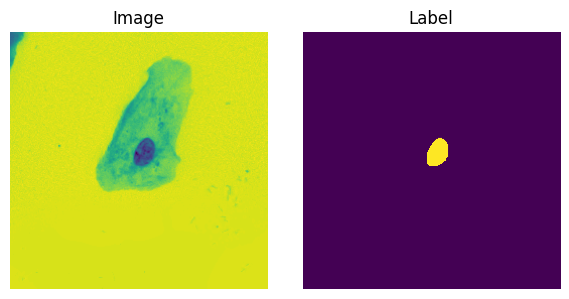

In [ ]:
image_index = 23 # Change this value to load a different image

# Use the Dataset directly to get a specific item by index
check_ds = Dataset(data=data_dicts, transform=train_transform)
check_data = check_ds[image_index][0]
image, label = (check_data["image"], check_data["label"])

print(f"Loaded image at index {image_index}. Image shape: {image.shape}")
print(f"Loaded label at index {image_index}. Label shape: {label.shape}")

for n in range(image.shape[0]):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(image[n, :, :])
    axes[0].axis("off")
    axes[0].set_title("Image")

    axes[1].imshow(label[n, :, :])
    axes[1].axis("off")
    axes[1].set_title("Label")

    plt.tight_layout()
    plt.show()

# Training a new model with changes

In [ ]:
drive_model = '/content/drive/MyDrive/nuclei_labelling/output/best_metric_model_randcrop01.pth'
local_model= '/content/output/best_metric_model_randcrop01.pth'

drive_output_dir = '/content/drive/MyDrive/nuclei_labelling/output'
local_output_dir = '/content/output'

In [ ]:
train_model = False

# Check if a model already exists
if os.path.exists(local_model):
    print(f"Model already exists locally at {local_model}. Skipping copy.")
else:
    print(f"Model not found locally. Checking Google Drive at {drive_output_dir}...")
    # Check if the source exists on Google Drive
    if os.path.exists(drive_model):
        print(f"Found output directory with model on Drive at '{drive_output_dir}'. Copying entire contents to '{local_output_dir}'...")
        os.makedirs(local_output_dir, exist_ok=True) # Ensure the destination directory is created
        shutil.copytree(drive_output_dir, local_output_dir, dirs_exist_ok=True)
        print("Directory copy complete.")
    else:
        print(f"WARNING: Model not found on Google Drive at {drive_output_dir} or locally. Training new model.")
        train_model = True

Model not found locally. Checking Google Drive at /content/drive/MyDrive/nuclei_labelling/output...
Found output directory with model on Drive at '/content/drive/MyDrive/nuclei_labelling/output'. Copying entire contents to '/content/output'...
Directory copy complete.


In [ ]:
if train_model:
# Re-creating training set and loader with updated transforms
  train_ds = CacheDataset(data=train_dicts, transform=train_transform, cache_rate=1.0, num_workers=4)
  train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)

# Re-creating validation set and loader with updated transforms
val_ds = CacheDataset(data=val_dicts, transform=val_transform, cache_rate=1.0, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=4)

Loading dataset: 100%|██████████| 134/134 [00:14<00:00,  9.24it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:

device = torch.device("cuda:0")

if train_model:
  for batch_data in train_loader:
      inputs, labels = (
          batch_data["image"].to(device),
          batch_data["label"].to(device),
      )
      print(f"Input image shape: {inputs.shape}") #
      print(f"Input label shape: {labels.shape}")
      print(inputs.max(), inputs.min())
      print(torch.unique(labels))

      break

Input image shape: torch.Size([64, 1, 256, 256])
Input label shape: torch.Size([64, 1, 256, 256])
metatensor(3.8889, device='cuda:0') metatensor(-0.2937, device='cuda:0')
metatensor([0., 1.], device='cuda:0')


In [ ]:

model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)
print(model)

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(
            (unit0): Convol

In [ ]:
if train_model:
  loss_function = DiceLoss(to_onehot_y=True, softmax=True)
  optimizer = torch.optim.Adam(model.parameters(), 1e-4)
  dice_metric = DiceMetric(include_background=False, reduction="mean")

In [ ]:
import os
import torch
from monai.transforms import Compose, AsDiscrete
from monai.data import decollate_batch
from monai.inferers import sliding_window_inference

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


if train_model:
  max_epochs = 100
  val_interval = 2
  best_metric = -1
  best_metric_epoch = -1
  epoch_loss_values = []
  metric_values = []

  post_pred = Compose([AsDiscrete(argmax=True, to_onehot=2)])
  post_label = Compose([AsDiscrete(to_onehot=2)])

  for epoch in range(max_epochs):
      print("-" * 10)
      print(f"epoch {epoch + 1}/{max_epochs}")
      model.train()
      epoch_loss = 0
      step = 0

      for batch_data in train_loader:
          step += 1
          inputs = batch_data["image"].to(device)
          labels = batch_data["label"].to(device)

          # Debugging: Ensure labels are strictly 0 or 1 before passing to loss
          # DiceLoss with to_onehot_y=True will crash if labels contain values >= out_channels (2)
          if labels.max() > 1:
              labels = (labels > 0.5).float()

          optimizer.zero_grad()
          outputs = model(inputs)

          loss = loss_function(outputs, labels)
          loss.backward()
          optimizer.step()

          epoch_loss += loss.item()
          if step % 10 == 0:
              print(f"{step}/{len(train_loader)}, train_loss: {loss.item():.4f}")

      epoch_loss /= step
      epoch_loss_values.append(epoch_loss)
      print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

      if (epoch + 1) % val_interval == 0:
          model.eval()
          with torch.no_grad():
              for val_data in val_loader:
                  val_inputs = val_data["image"].to(device)
                  val_labels = val_data["label"].to(device)

                  if val_labels.max() > 1:
                      val_labels = (val_labels > 0.5).float()

                  roi_size = (256, 256)
                  sw_batch_size = 4
                  val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)

                  val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                  val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                  dice_metric(y_pred=val_outputs, y=val_labels)

              metric = dice_metric.aggregate().item()
              dice_metric.reset()
              metric_values.append(metric)

              if metric > best_metric:
                  best_metric = metric
                  best_metric_epoch = epoch + 1
                  torch.save(model.state_dict(), "best_metric_model_randcrop01.pth")
                  print("saved new best metric model")

              print(f"current epoch: {epoch + 1} current mean dice: {metric:.4f} best mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}")

----------
epoch 1/100
10/34, train_loss: 0.4944
20/34, train_loss: 0.4600
30/34, train_loss: 0.4913
epoch 1 average loss: 0.4856
----------
epoch 2/100
10/34, train_loss: 0.4631
20/34, train_loss: 0.5221
30/34, train_loss: 0.4405
epoch 2 average loss: 0.4786
saved new best metric model
current epoch: 2 current mean dice: 0.5110 best mean dice: 0.5110 at epoch: 2
----------
epoch 3/100
10/34, train_loss: 0.5266
20/34, train_loss: 0.4940
30/34, train_loss: 0.4372
epoch 3 average loss: 0.4708
----------
epoch 4/100
10/34, train_loss: 0.4621
20/34, train_loss: 0.4473
30/34, train_loss: 0.4313
epoch 4 average loss: 0.4661
current epoch: 4 current mean dice: 0.5102 best mean dice: 0.5110 at epoch: 2
----------
epoch 5/100
10/34, train_loss: 0.4625
20/34, train_loss: 0.4185
30/34, train_loss: 0.4592
epoch 5 average loss: 0.4612
----------
epoch 6/100
10/34, train_loss: 0.4644
20/34, train_loss: 0.4678
30/34, train_loss: 0.4425
epoch 6 average loss: 0.4561
saved new best metric model
current 

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


current epoch: 94 current mean dice: 0.8942 best mean dice: 0.8953 at epoch: 90
----------
epoch 95/100
10/34, train_loss: 0.0366
20/34, train_loss: 0.0366
30/34, train_loss: 0.0456
epoch 95 average loss: 0.0419
----------
epoch 96/100
10/34, train_loss: 0.0316
20/34, train_loss: 0.0401
30/34, train_loss: 0.0464
epoch 96 average loss: 0.0422
current epoch: 96 current mean dice: 0.8932 best mean dice: 0.8953 at epoch: 90
----------
epoch 97/100
10/34, train_loss: 0.0445
20/34, train_loss: 0.0360
30/34, train_loss: 0.0407
epoch 97 average loss: 0.0422
----------
epoch 98/100
10/34, train_loss: 0.0442
20/34, train_loss: 0.0428
30/34, train_loss: 0.0374
epoch 98 average loss: 0.0404
saved new best metric model
current epoch: 98 current mean dice: 0.8959 best mean dice: 0.8959 at epoch: 98
----------
epoch 99/100
10/34, train_loss: 0.0443
20/34, train_loss: 0.0425
30/34, train_loss: 0.0470
epoch 99 average loss: 0.0422
----------
epoch 100/100
10/34, train_loss: 0.0508
20/34, train_loss: 0.

In [ ]:
if train_model:
  print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")

train completed, best_metric: 0.8959 at epoch: 98


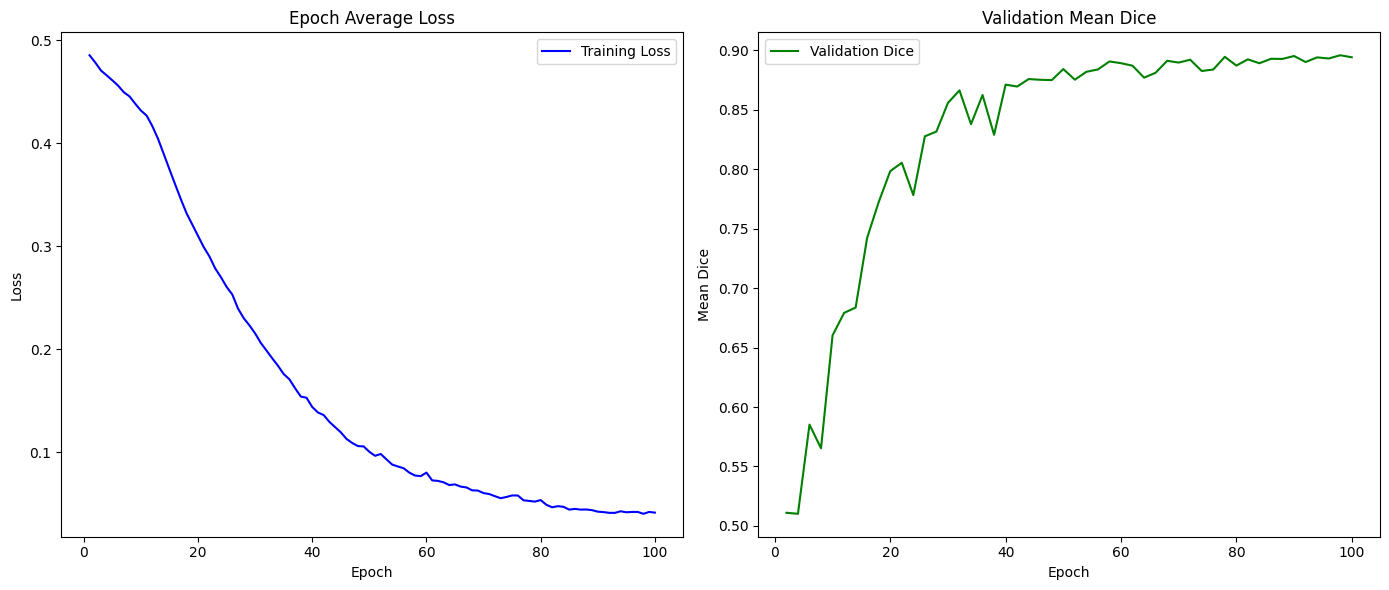

In [ ]:
if train_model:
  # Define plot parameters
  plt.figure(figsize=(14, 6))

  # Plot Epoch Average Loss
  plt.subplot(1, 2, 1)
  plt.title("Epoch Average Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  x_loss = [i + 1 for i in range(len(epoch_loss_values))]
  y_loss = epoch_loss_values
  plt.plot(x_loss, y_loss, color='blue', label='Training Loss')
  plt.legend()

  # Plot Validation Mean Dice
  plt.subplot(1, 2, 2)
  plt.title("Validation Mean Dice")
  plt.xlabel("Epoch")
  plt.ylabel("Mean Dice")
  x_dice = [val_interval * (i + 1) for i in range(len(metric_values))]
  y_dice = metric_values
  plt.plot(x_dice, y_dice, color='green', label='Validation Dice')
  plt.legend()

  plt.savefig('rand_crop_loss_dice.png')
  plt.tight_layout()
  plt.show()


In [ ]:
model.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (adn): ADN(
            (N): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(
            (unit0): Convol

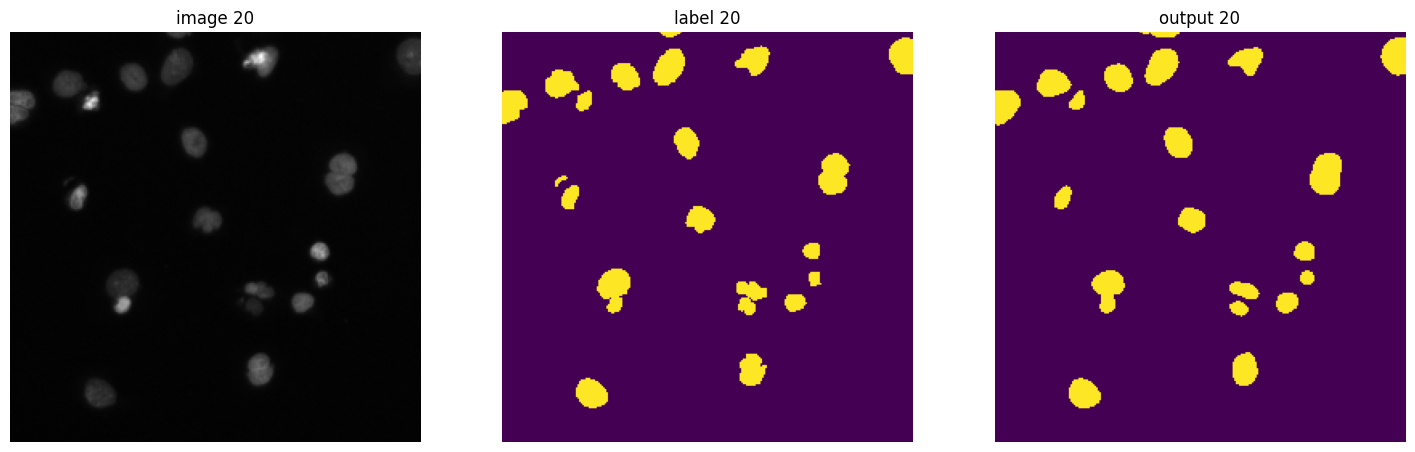

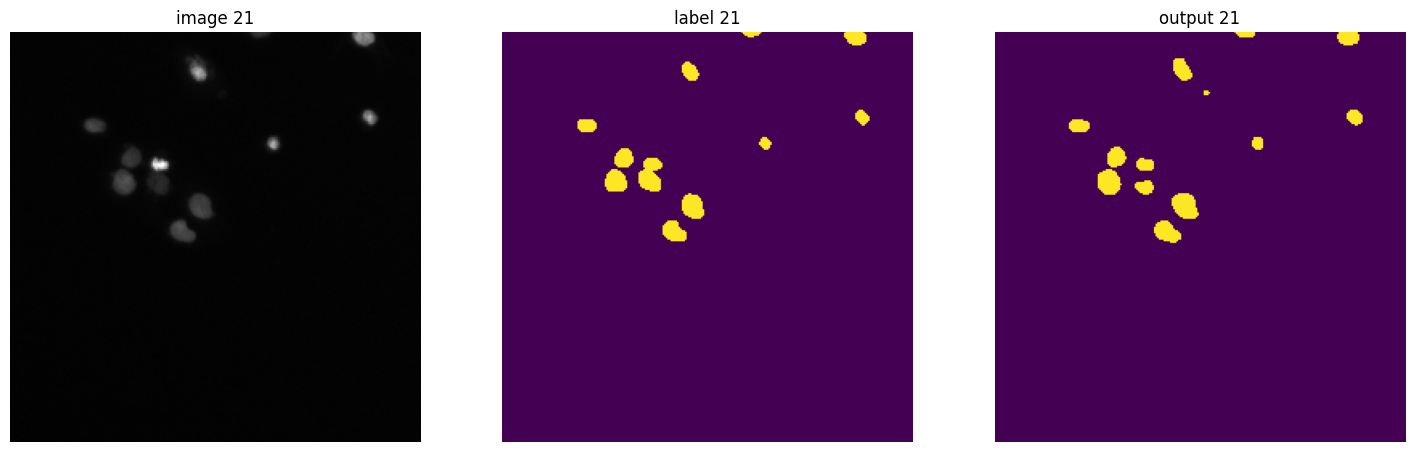

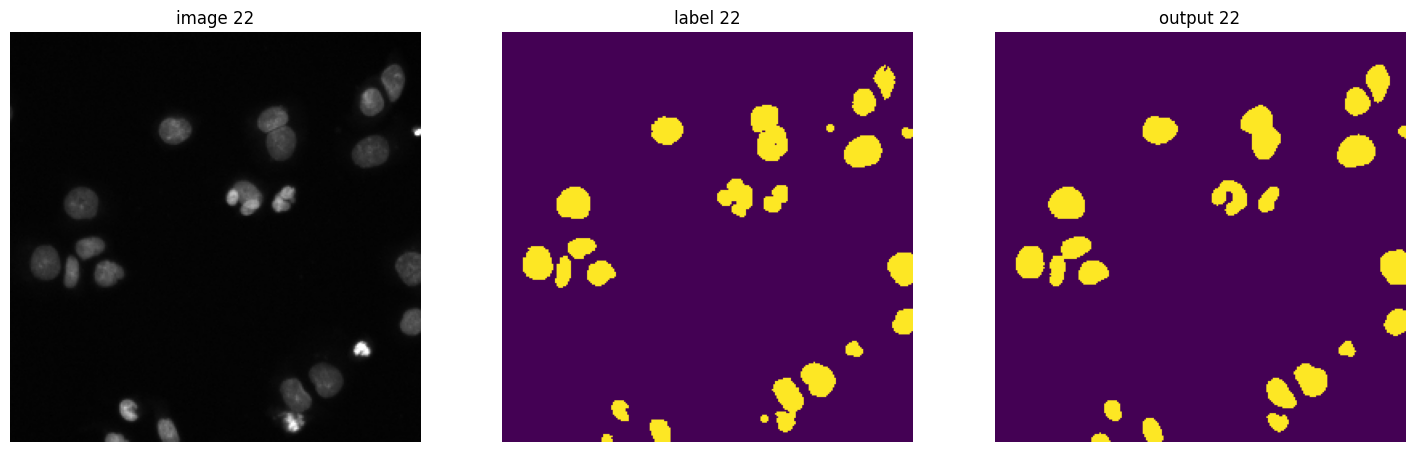

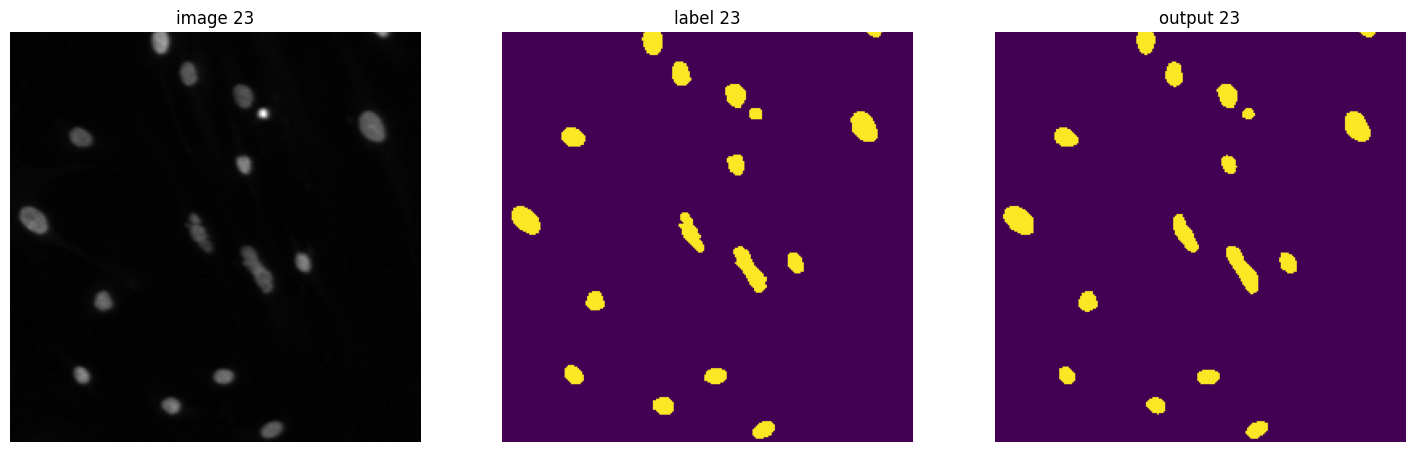

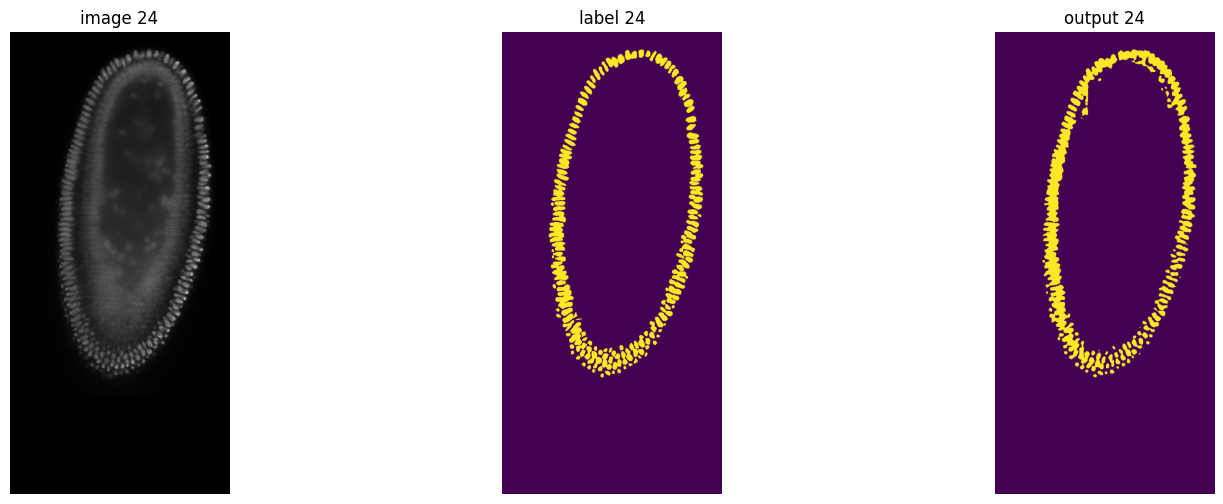

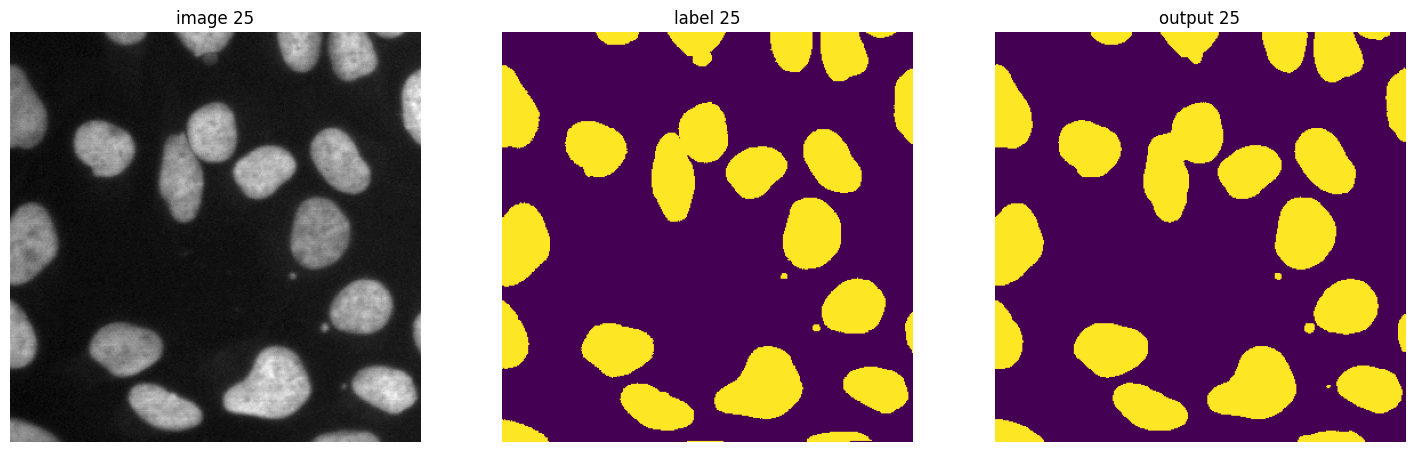

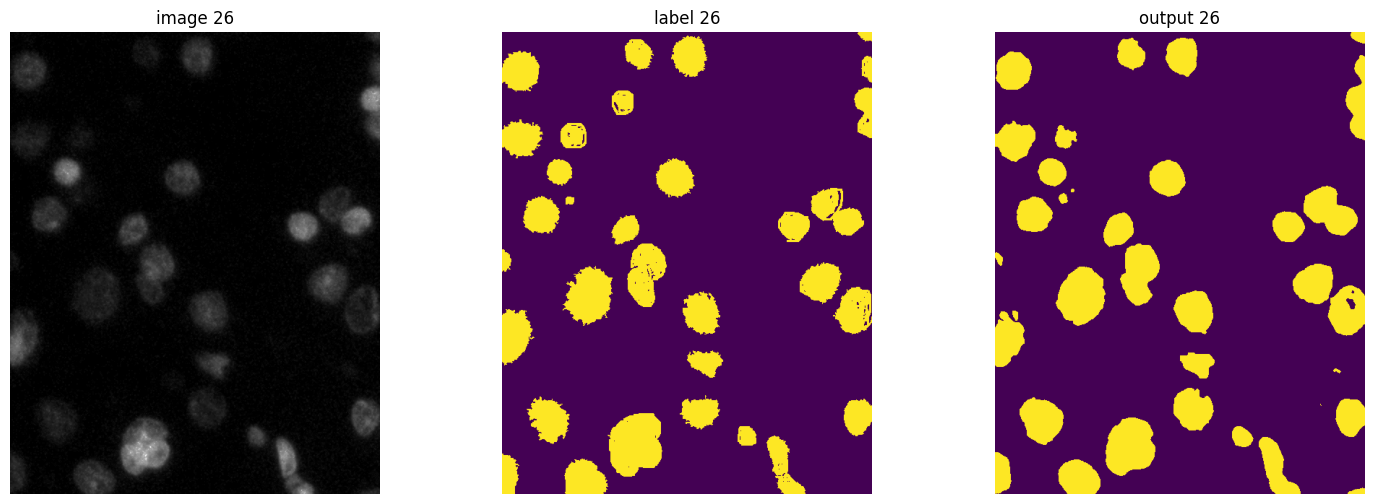

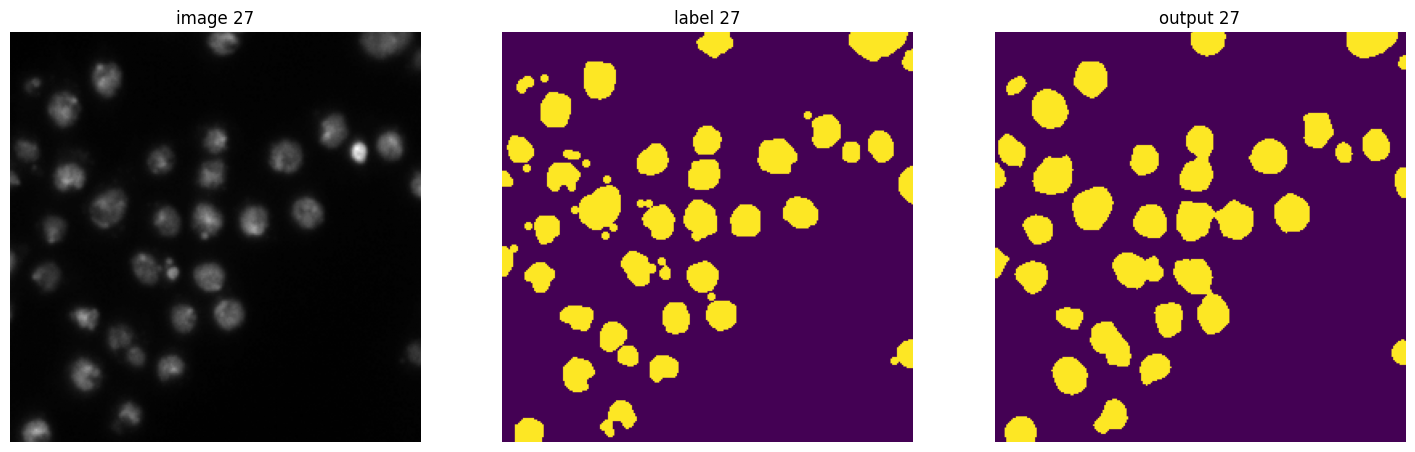

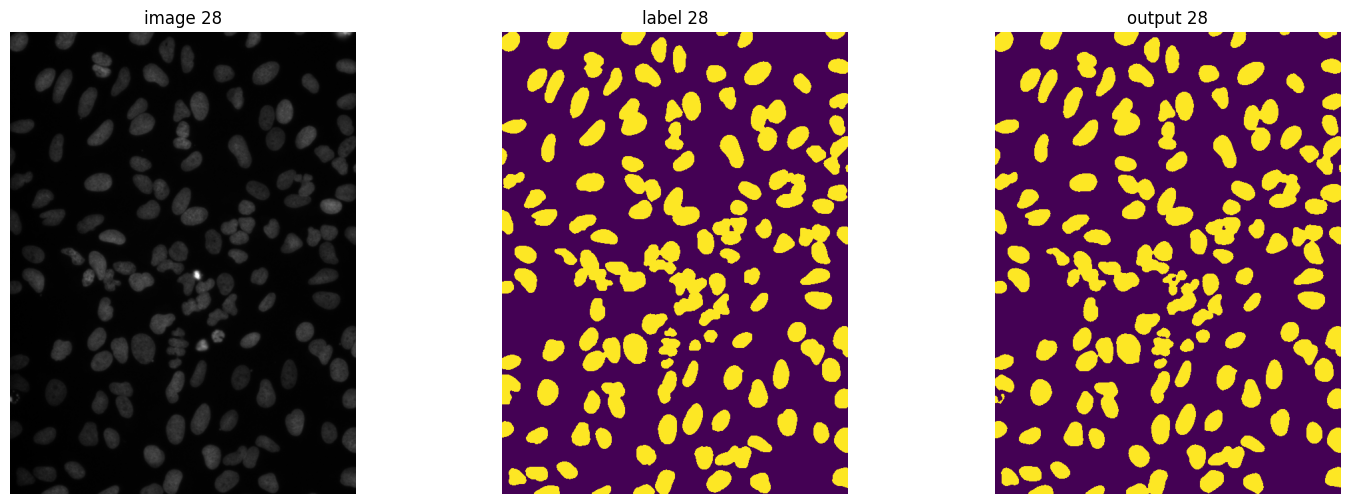

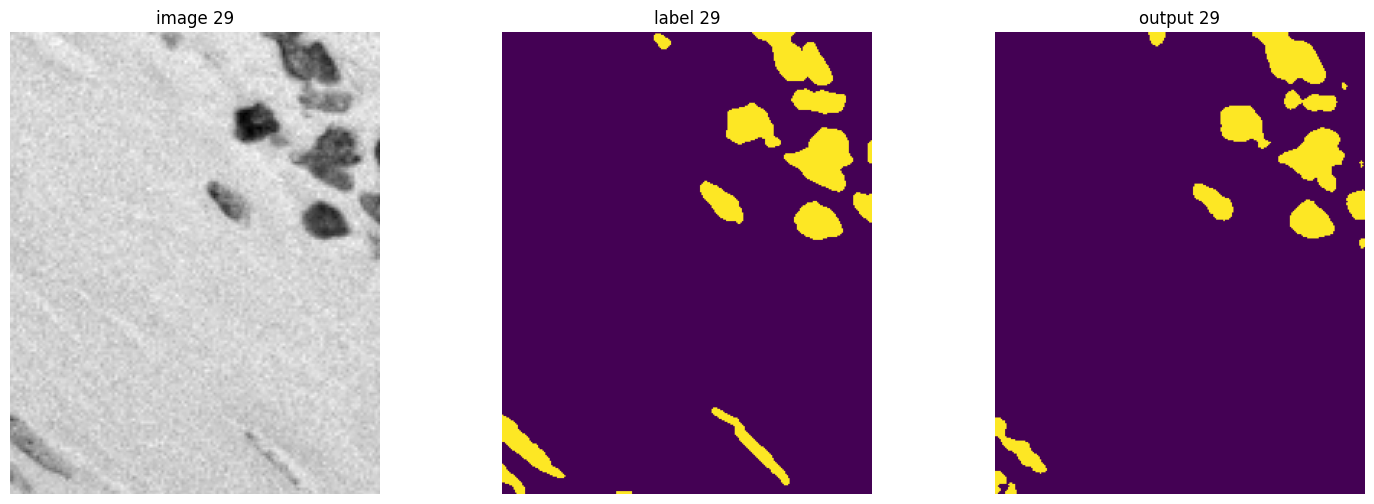

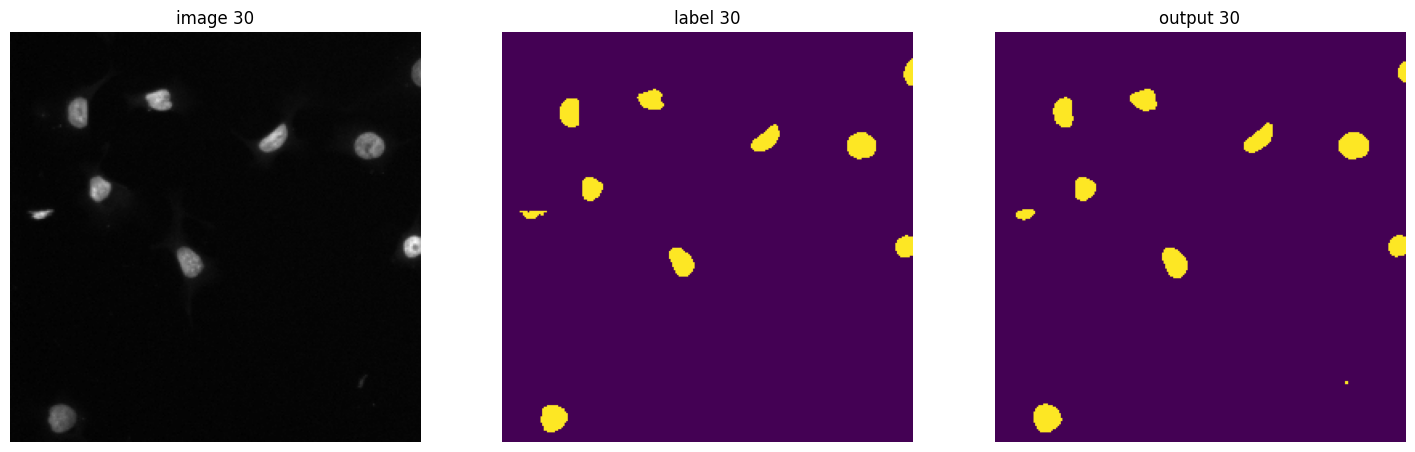

In [ ]:
import torch
import matplotlib.pyplot as plt
from monai.inferers import sliding_window_inference

start = 20
stop = 30
# Perform inference on validation data using the best model
model.eval()
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        if i < start:
            continue
        if i > stop:
            break

        # Update roi_size to 2D dimensions (256, 256)
        roi_size = (256, 256)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(
            val_data["image"].to(device),
            roi_size,
            sw_batch_size,
            model
        )

        # Plot the 2D results
        plt.figure("check", (18, 6))

        # Plot original 2D image
        plt.subplot(1, 3, 1)
        plt.title(f"image {i}")
        plt.imshow(val_data["image"][0, 0, :, :], cmap="gray")
        plt.axis("off")

        # Plot ground truth 2D label
        plt.subplot(1, 3, 2)
        plt.title(f"label {i}")
        plt.imshow(val_data["label"][0, 0, :, :])
        plt.axis("off")

        # Plot model 2D output
        plt.subplot(1, 3, 3)
        plt.title(f"output {i}")
        # Use argmax to get the class prediction and remove batch/channel dims
        plt.imshow(torch.argmax(val_outputs, dim=1).detach().cpu()[0, :, :])
        plt.axis("off")

        plt.show()

        # # Break loop after 3 iterations for visualization
        # if i == 10:
        #     break